# Analyse de données e-commerce

Analyse et intégration de données clients, produits, commandes, paiements et avis.

Le notebook couvre :
- le contrôle qualité des données ;
- le nettoyage et l'intégration ;
- l'exploration des indicateurs clés ;
- la construction d'un modèle dimensionnel.

In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_data_dir():
    candidates = [Path("."), Path("/mnt/data"), Path("/mnt/user-data/uploads")]
    for c in candidates:
        if (c / "clients.csv").exists():
            return c
    raise FileNotFoundError(
        "clients.csv introuvable : placez les 5 fichiers CSV a cote de ce notebook."
    )

DATA_DIR = find_data_dir()

FILES = {
    "clients": DATA_DIR / "clients.csv",
    "produits": DATA_DIR / "produits.csv",
    "commandes": DATA_DIR / "commandes.csv",
    "paiements": DATA_DIR / "paiements.csv",
    "avis_clients": DATA_DIR / "avis_clients.csv",
}

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Dossier de donnees utilise :", DATA_DIR.resolve())

Dossier de donnees utilise : /home/nekena/Downloads/bobody


## 1. Diagnostic des données

Évaluation de la structure, de la qualité et des principales anomalies des cinq sources.

In [2]:
raw = {name: pd.read_csv(path) for name, path in FILES.items()}

for name, df in raw.items():
    print(f"\n{name}.csv : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
    display(pd.DataFrame({
        "type": df.dtypes.astype(str),
        "valeurs_manquantes": df.isna().sum(),
        "valeurs_distinctes": df.nunique(),
    }))


clients.csv : 207 lignes x 8 colonnes


,type,valeurs_manquantes,valeurs_distinctes
id_client,str,0,207
nom,str,0,26
prenom,str,0,37
email,str,0,200
telephone,str,0,200
ville,str,0,10
region,str,0,8
date_inscription,str,0,172



produits.csv : 59 lignes x 5 colonnes


,type,valeurs_manquantes,valeurs_distinctes
id_produit,str,0,59
nom_produit,str,0,59
categorie,str,0,10
prix_unitaire,float64,5,52
stock_disponible,int64,0,53



commandes.csv : 1,223 lignes x 9 colonnes


,type,valeurs_manquantes,valeurs_distinctes
id_commande,str,0,709
id_client,str,0,209
id_produit,str,0,59
quantite,int64,0,4
prix_unitaire,float64,0,150
montant_ligne,float64,0,282
date_commande,str,0,1006
date_livraison,str,492,303
statut,str,0,15



paiements.csv : 719 lignes x 6 colonnes


,type,valeurs_manquantes,valeurs_distinctes
id_paiement,str,0,719
id_commande,str,0,719
montant_paye,float64,0,492
mode_paiement,str,0,4
date_paiement,str,0,708
statut_paiement,str,0,3



avis_clients.csv : 406 lignes x 5 colonnes


,type,valeurs_manquantes,valeurs_distinctes
id_avis,str,0,400
id_commande,str,0,400
note,float64,9,9
commentaire,str,0,20
date_avis,str,0,252


In [3]:
clients, produits = raw["clients"].copy(), raw["produits"].copy()
commandes, paiements, avis = raw["commandes"].copy(), raw["paiements"].copy(), raw["avis_clients"].copy()

print("Doublons de lignes stricts :")
for name, df in raw.items():
    print(f"  - {name} : {df.duplicated().sum()}")

print("\nUnicite des identifiants :")
for name, df, key in [
    ("clients", clients, "id_client"),
    ("produits", produits, "id_produit"),
    ("commandes", commandes, "id_commande"),
    ("paiements", paiements, "id_paiement"),
    ("avis_clients", avis, "id_avis"),
]:
    print(f"  - {name}.{key} : {df[key].nunique()} valeurs distinctes / {len(df)} lignes")
print("    (commandes.id_commande n'est PAS unique : une commande peut contenir plusieurs produits,")
print("     donc plusieurs lignes. C'est attendu, ce n'est pas une anomalie.)")

print("\nCles etrangeres orphelines :")
print("  - commandes -> clients  :", (~commandes.id_client.isin(clients.id_client)).sum())
print("  - commandes -> produits :", (~commandes.id_produit.isin(produits.id_produit)).sum())
print("  - paiements -> commandes:", (~paiements.id_commande.isin(commandes.id_commande)).sum())
print("  - avis      -> commandes:", (~avis.id_commande.isin(commandes.id_commande)).sum())

orphan_ids = commandes.loc[~commandes.id_client.isin(clients.id_client), "id_client"]
print(f"\nIdentifiants clients absents : {orphan_ids.nunique()} identifiants distincts,")
print(f"concernant {orphan_ids.shape[0]} lignes de commande / "
      f"{commandes.loc[commandes.id_client.isin(orphan_ids.unique()), 'id_commande'].nunique()} commandes distinctes.")
print(sorted(orphan_ids.unique()))

Doublons de lignes stricts :
  - clients : 0
  - produits : 0
  - commandes : 0
  - paiements : 0
  - avis_clients : 6

Unicite des identifiants :
  - clients.id_client : 207 valeurs distinctes / 207 lignes
  - produits.id_produit : 59 valeurs distinctes / 59 lignes
  - commandes.id_commande : 709 valeurs distinctes / 1223 lignes
  - paiements.id_paiement : 719 valeurs distinctes / 719 lignes
  - avis_clients.id_avis : 400 valeurs distinctes / 406 lignes
    (commandes.id_commande n'est PAS unique : une commande peut contenir plusieurs produits,
     donc plusieurs lignes. C'est attendu, ce n'est pas une anomalie.)

Cles etrangeres orphelines :
  - commandes -> clients  : 14
  - commandes -> produits : 0
  - paiements -> commandes: 10
  - avis      -> commandes: 0

Identifiants clients absents : 14 identifiants distincts,
concernant 14 lignes de commande / 14 commandes distinctes.
['CLI9001', 'CLI9002', 'CLI9003', 'CLI9004', 'CLI9005', 'CLI9006', 'CLI9007', 'CLI9008', 'CLI9009', 'CLI90

In [4]:
print("Categories produit avant normalisation :")
print(produits["categorie"].value_counts(dropna=False).to_string())

print("\nStatuts de commande avant normalisation :")
print(commandes["statut"].value_counts(dropna=False).to_string())

print("\nVilles clients avant normalisation :")
print(clients["ville"].value_counts(dropna=False).to_string())

print("\nNotes d'avis (avant tout filtrage) :")
print(avis["note"].value_counts(dropna=False).sort_index().to_string())

print("\nPrix catalogue manquants (produits.prix_unitaire) :", produits["prix_unitaire"].isna().sum())
print("Paiements negatifs :", (paiements["montant_paye"] < 0).sum())

clients["email_norm"] = clients["email"].str.strip().str.lower()
clients["telephone_norm"] = clients["telephone"].str.replace(r"\D", "", regex=True)
dup_mask = clients.duplicated(subset=["email_norm", "telephone_norm"], keep=False)
print(f"\nClients en doublon (meme email + meme telephone) : {dup_mask.sum()} lignes / "
      f"{clients.loc[dup_mask, 'email_norm'].nunique()} paires")
display(clients.loc[dup_mask, ["id_client","nom","prenom","email","telephone","date_inscription","email_norm"]]
        .sort_values("email_norm").drop(columns="email_norm"))

print("\nDoublons stricts d'avis (lignes identiques sur toutes les colonnes) :")
display(avis[avis.duplicated(keep=False)].sort_values(list(avis.columns)))

Categories produit avant normalisation :
categorie
Vetement        9
Electronique    8
Alimentation    8
Loisir          8
Beaute          8
Maison          7
Bagagerie       5
maison          3
electronique    2
VETEMENT        1

Statuts de commande avant normalisation :
statut
Livré            150
livré            150
Livre            148
LIVRE            146
livre            137
en traitement     59
Expedie           57
Expédié           54
annule            53
En traitement     52
EN TRAITEMENT     48
Annulé            47
Annule            45
expedie           41
ANNULE            36

Villes clients avant normalisation :
ville
Antsirabe       32
Antsiranana     28
Toamasina       27
Toliara         26
Fianarantsoa    24
Mahajanga       22
Morondava       22
Antananarivo    21
Antsirabé        3
antananarivo     2

Notes d'avis (avant tout filtrage) :
note
-2.00      2
0.00       3
1.00      41
2.00      54
3.00      85
4.00     100
5.00     107
6.00       2
10.00      3
NaN       

,id_client,nom,prenom,email,telephone,date_inscription
184,CLI0185,Rakoto,Antsa,antsa.rakoto185@mail.mg,+261 34 97 674 60,2024-02-29
204,CLI0205,RAKOTO,Antsa,antsa.rakoto185@mail.mg,+261 34 97 674 60,2024-02-29
34,CLI0035,Randria,Fetra,fetra.randria35@mail.mg,+261 32 49 470 13,2024-12-22
202,CLI0203,RANDRIA,Fetra,fetra.randria35@mail.mg,+261 32 49 470 13,2024-12-22
58,CLI0059,Rafanomezantsoa,Haja,haja.rafanomezantsoa59@mail.mg,0337464450,2024-04-10
200,CLI0201,rafanomezantsoa,Haja,haja.rafanomezantsoa59@mail.mg,0337464450,2024-04-10
95,CLI0096,Andrianjafy,Hery,hery.andrianjafy96@mail.mg,0323731443,2024-09-04
206,CLI0207,andrianjafy,Hery,hery.andrianjafy96@mail.mg,0323731443,2024-09-04
102,CLI0103,Rasoa,Mamy,mamy.rasoa103@mail.mg,0345571230,2024-10-17
203,CLI0204,RASOA,Mamy,mamy.rasoa103@mail.mg,0345571230,2024-10-17



Doublons stricts d'avis (lignes identiques sur toutes les colonnes) :


,id_avis,id_commande,note,commentaire,date_avis
313,AVI00027,CMD00491,3.00,Attendu mieux pour ce prix,2025-06-12
362,AVI00027,CMD00491,3.00,Attendu mieux pour ce prix,2025-06-12
106,AVI00216,CMD00647,5.00,Excellent rapport qualite prix,2025-10-07
252,AVI00216,CMD00647,5.00,Excellent rapport qualite prix,2025-10-07
319,AVI00306,CMD00691,2.00,Ne correspond pas tout a fait,2025-07-11
357,AVI00306,CMD00691,2.00,Ne correspond pas tout a fait,2025-07-11
19,AVI00310,CMD00656,3.00,Livraison lente mais produit ok,2025-04-11
194,AVI00310,CMD00656,3.00,Livraison lente mais produit ok,2025-04-11
49,AVI00327,CMD00036,3.00,Livraison lente mais produit ok,2025-09-02
180,AVI00327,CMD00036,3.00,Livraison lente mais produit ok,2025-09-02


### Validation des montants

Comparaison des montants de ligne, des prix unitaires, des quantités et des paiements.

In [5]:
commandes["montant_ligne_calc"] = commandes["prix_unitaire"] * commandes["quantite"]
mismatch_mask = ~np.isclose(commandes["montant_ligne_calc"], commandes["montant_ligne"], atol=1)
mismatch_orders = commandes.loc[mismatch_mask, "id_commande"].unique()
print(f"Lignes ou montant_ligne != prix_unitaire*quantite : {mismatch_mask.sum()} "
      f"({len(mismatch_orders)} commandes concernees)")

order_total_orig = commandes.groupby("id_commande")["montant_ligne"].sum()
order_total_calc = commandes.groupby("id_commande")["montant_ligne_calc"].sum()
pay_valid = paiements.loc[
    (paiements["statut_paiement"] == "Valide") & (paiements["montant_paye"] > 0)
].set_index("id_commande")["montant_paye"]

common = pd.Index(mismatch_orders).intersection(pay_valid.index)
match_orig = np.isclose(order_total_orig.loc[common], pay_valid.loc[common], atol=1)
match_calc = np.isclose(order_total_calc.loc[common], pay_valid.loc[common], atol=1)

print(f"\nParmi elles, commandes avec un paiement valide positif exploitable : {len(common)}")
print(f"  - correspondance avec la somme de montant_ligne (brut)   : {match_orig.mean():.1%} ({match_orig.sum()}/{len(common)})")
print(f"  - correspondance avec la somme de prix_unitaire*quantite : {match_calc.mean():.1%} ({match_calc.sum()}/{len(common)})")

assert match_orig.mean() == 1.0, "montant_ligne brut devrait correspondre a 100% des paiements valides"
assert match_calc.mean() == 0.0, "le recalcul ne devrait matcher aucun paiement (sinon revoir l'hypothese)"
print("\n-> Sur les commandes en ecart, montant_ligne (brut) correspond EXACTEMENT au paiement encaisse")
print("   dans 100% des cas verifiables ; le recalcul prix_unitaire*quantite ne correspond dans AUCUN cas.")
print("   Decision : on NE recalcule PAS montant_ligne. C'est prix_unitaire qui differe (remise ou")
print("   prix negocie a la ligne, non capture par le catalogue) -- ce n'est pas une erreur de saisie,")
print("   c'est une information commerciale reelle. On la garde telle quelle et on la signale a la")
print("   plateforme comme point a documenter (pas a corriger).")

Lignes ou montant_ligne != prix_unitaire*quantite : 50 (49 commandes concernees)

Parmi elles, commandes avec un paiement valide positif exploitable : 40
  - correspondance avec la somme de montant_ligne (brut)   : 100.0% (40/40)
  - correspondance avec la somme de prix_unitaire*quantite : 0.0% (0/40)

-> Sur les commandes en ecart, montant_ligne (brut) correspond EXACTEMENT au paiement encaisse
   dans 100% des cas verifiables ; le recalcul prix_unitaire*quantite ne correspond dans AUCUN cas.
   Decision : on NE recalcule PAS montant_ligne. C'est prix_unitaire qui differe (remise ou
   prix negocie a la ligne, non capture par le catalogue) -- ce n'est pas une erreur de saisie,
   c'est une information commerciale reelle. On la garde telle quelle et on la signale a la
   plateforme comme point a documenter (pas a corriger).


### Validation des paiements négatifs

Contrôle des montants négatifs afin d'identifier les erreurs de signe.

In [6]:
order_total = commandes.groupby("id_commande")["montant_ligne"].sum()
neg = paiements.loc[paiements["montant_paye"] < 0].copy()
neg["montant_commande"] = neg["id_commande"].map(order_total)
neg["signe_errone"] = np.isclose(neg["montant_paye"].abs(), neg["montant_commande"], atol=1)
display(neg[["id_paiement","id_commande","montant_paye","statut_paiement","montant_commande","signe_errone"]])

assert neg["signe_errone"].all(), "au moins un paiement negatif reste inexplique"
print(f"\nLes {len(neg)} paiements negatifs correspondent tous exactement (valeur absolue) au montant de")
print("leur commande, quel que soit le statut de paiement. Decision : bug de signe a l'export -> on")
print("corrige en valeur absolue. A signaler a la plateforme : le signe de montant_paye n'est pas fiable.")

,id_paiement,id_commande,montant_paye,statut_paiement,montant_commande,signe_errone
65,PAY00650,CMD00650,"-64,100.00",Rembourse,"64,100.00",True
106,PAY00697,CMD00697,"-97,200.00",Valide,"97,200.00",True
354,PAY00122,CMD00122,"-94,300.00",Echoue,"94,300.00",True
500,PAY00525,CMD00525,"-486,300.00",Echoue,"486,300.00",True
555,PAY00533,CMD00533,"-112,600.00",Echoue,"112,600.00",True
646,PAY00310,CMD00310,"-464,300.00",Valide,"464,300.00",True
690,PAY00390,CMD00390,"-2,803,000.00",Valide,"2,803,000.00",True
709,PAY00587,CMD00587,"-27,800.00",Valide,"27,800.00",True



Les 8 paiements negatifs correspondent tous exactement (valeur absolue) au montant de
leur commande, quel que soit le statut de paiement. Decision : bug de signe a l'export -> on
corrige en valeur absolue. A signaler a la plateforme : le signe de montant_paye n'est pas fiable.


## Décisions de nettoyage

Synthèse des règles appliquées pour normaliser et fiabiliser les données.

## 2. Construction de la table analytique

Nettoyage des sources et intégration dans une table au grain d'une ligne par produit commandé.

In [7]:
def strip_accents(s):
    if pd.isna(s):
        return s
    return unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")

def normalize_text(series):
    return series.astype("string").str.strip().str.lower().map(strip_accents)

def normalize_title(series):
    return normalize_text(series).str.title()

MONTHS_FR = {
    "janvier": "01", "fevrier": "02", "mars": "03", "avril": "04", "mai": "05", "juin": "06",
    "juillet": "07", "aout": "08", "septembre": "09", "octobre": "10", "novembre": "11", "decembre": "12",
}

def parse_mixed_date(value):
    if pd.isna(value):
        return pd.NaT
    s = str(value).strip()
    if re.match(r"^\d{4}-\d{2}-\d{2}", s):
        return pd.to_datetime(s, errors="coerce")
    m = re.match(r"^(\d{1,2})/(\d{1,2})/(\d{4})(?:\s+(\d{1,2}):(\d{2}))?$", s)
    if m:
        d, mo, y, hh, mm = m.groups()
        suffix = f" {hh.zfill(2)}:{mm}" if hh else ""
        return pd.to_datetime(f"{y}-{mo.zfill(2)}-{d.zfill(2)}{suffix}", errors="coerce")
    m = re.match(r"^(\d{1,2})\s+([A-Za-zA-\xff]+)\s+(\d{4})(?:\s+(\d{1,2}):(\d{2}))?$", s)
    if m:
        d, month, y, hh, mm = m.groups()
        month_num = MONTHS_FR.get(strip_accents(month.lower()))
        if month_num:
            suffix = f" {hh.zfill(2)}:{mm}" if hh else ""
            return pd.to_datetime(f"{y}-{month_num}-{d.zfill(2)}{suffix}", errors="coerce")
    return pd.NaT

STATUT_MAP = {
    "livre": "Livree", "livree": "Livree",
    "expedie": "Expediee", "expediee": "Expediee",
    "en traitement": "En traitement",
    "annule": "Annulee", "annulee": "Annulee",
}
def normalize_statut(series):
    return normalize_text(series).map(STATUT_MAP)

def money(x):
    if pd.isna(x):
        return "n/d"
    return f"{x:,.0f} Ar".replace(",", " ")

print("Fonctions de normalisation definies.")

Fonctions de normalisation definies.


In [8]:
canonical_map = (
    clients.sort_values("id_client")
    .groupby(["email_norm", "telephone_norm"])["id_client"].first()
)
clients["id_client_canon"] = clients.set_index(["email_norm", "telephone_norm"]).index.map(canonical_map)
client_id_map = clients.set_index("id_client")["id_client_canon"].to_dict()
n_remapped = (clients["id_client"] != clients["id_client_canon"]).sum()

clients["ville_norm"] = normalize_title(clients["ville"])
clients["region_norm"] = normalize_title(clients["region"])

dim_client = (
    clients.loc[clients["id_client"] == clients["id_client_canon"],
                ["id_client_canon", "nom", "prenom", "email_norm", "telephone", "ville_norm", "region_norm", "date_inscription"]]
    .rename(columns={"id_client_canon": "id_client", "email_norm": "email", "ville_norm": "ville", "region_norm": "region"})
    .reset_index(drop=True)
)
assert dim_client["id_client"].is_unique

print(f"Clients bruts : {len(clients)} -> {n_remapped} lignes remappees vers un id canonique "
      f"-> dim_client : {len(dim_client)} clients uniques")
display(dim_client.head(3))

Clients bruts : 207 -> 7 lignes remappees vers un id canonique -> dim_client : 200 clients uniques


,id_client,nom,prenom,email,telephone,ville,region,date_inscription
0,CLI0001,Rabe,Tantely,tantely.rabe1@mail.mg,0326 812 251,Antsirabe,Vakinankaratra,2024-11-25
1,CLI0002,Andrianina,Mendrika,mendrika.andrianina2@mail.mg,+261 34 67 579 19,Fianarantsoa,Haute Matsiatra,2024-09-08
2,CLI0003,Rasoa,Miora,miora.rasoa3@mail.mg,0322110528,Toliara,Atsimo-Andrefana,2024-05-11


In [9]:
produits["categorie_norm"] = normalize_title(produits["categorie"])
median_price_by_product = commandes.groupby("id_produit")["prix_unitaire"].median()
produits["prix_unitaire_ref"] = produits["prix_unitaire"].fillna(produits["id_produit"].map(median_price_by_product))

dim_produit = produits[["id_produit", "nom_produit", "categorie_norm", "prix_unitaire_ref", "stock_disponible"]].rename(
    columns={"categorie_norm": "categorie", "prix_unitaire_ref": "prix_unitaire"}
)
assert dim_produit["id_produit"].is_unique
assert dim_produit["prix_unitaire"].notna().all()

print(f"Produits : {len(dim_produit)}, dont {produits['prix_unitaire'].isna().sum()} prix catalogue completes par la mediane")
display(dim_produit.head(3))

Produits : 59, dont 5 prix catalogue completes par la mediane


,id_produit,nom_produit,categorie,prix_unitaire,stock_disponible
0,PRD001,Smartphone,Electronique,"559,100.00",27
1,PRD002,Ecouteurs sans fil,Electronique,"796,800.00",112
2,PRD003,Chargeur rapide,Electronique,"169,200.00",196


In [10]:
cmd = commandes.copy()
cmd["id_client_canon"] = cmd["id_client"].map(client_id_map)
cmd["date_commande_dt"] = cmd["date_commande"].map(parse_mixed_date)
cmd["date_livraison_dt"] = pd.to_datetime(cmd["date_livraison"], errors="coerce")
cmd["statut_norm"] = normalize_statut(cmd["statut"])
cmd["montant_ligne_final"] = cmd["montant_ligne"]  # conserve tel quel, cf verification ci-dessus

assert cmd["date_commande_dt"].isna().sum() == 0, "des dates de commande ne sont pas parsees"
assert cmd["statut_norm"].isna().sum() == 0, "des statuts ne sont pas reconnus"

n_client_inconnu_lignes = cmd["id_client_canon"].isna().sum()
n_client_inconnu_commandes = cmd.loc[cmd["id_client_canon"].isna(), "id_commande"].nunique()
incoh_liv = cmd.loc[
    cmd["date_livraison_dt"].notna()
    & (cmd["date_livraison_dt"].dt.normalize() < cmd["date_commande_dt"].dt.normalize())
]

print(f"Lignes de commande avec client inconnu : {n_client_inconnu_lignes} ({n_client_inconnu_commandes} commandes)")
print(f"Lignes avec livraison avant commande (signalees, non corrigees) : {len(incoh_liv)}")
print("Statuts normalises :", sorted(cmd['statut_norm'].unique()))

Lignes de commande avec client inconnu : 14 (14 commandes)
Lignes avec livraison avant commande (signalees, non corrigees) : 11
Statuts normalises : ['Annulee', 'En traitement', 'Expediee', 'Livree']


In [11]:
pay = paiements.copy()
pay["statut_paiement_norm"] = normalize_text(pay["statut_paiement"]).str.title()
pay["montant_paye_corrige"] = pay["montant_paye"].abs()

n_pay_orphelins = (~pay["id_commande"].isin(cmd["id_commande"])).sum()
pay_scope = pay.loc[pay["id_commande"].isin(cmd["id_commande"])].copy()
assert pay_scope["id_commande"].is_unique, "Plusieurs paiements sont rattachés à une même commande."

order_client = cmd[["id_commande", "id_client_canon"]].drop_duplicates("id_commande").rename(columns={"id_client_canon": "id_client"})
pay_scope = pay_scope.merge(order_client, on="id_commande", how="left")

print(f"Paiements orphelins exclus de la table finale : {n_pay_orphelins}")
print(
    f"Paiements rattachés à une commande valide : {len(pay_scope)} "
    f"(couverture : {len(pay_scope) / cmd['id_commande'].nunique():.1%})"
)


Paiements orphelins exclus de la table finale : 10
Paiements rattachés à une commande valide : 709 (couverture : 100.0%)


In [12]:
avis_c = avis.drop_duplicates().copy()
n_avis_dup = len(avis) - len(avis_c)
avis_c["date_avis_dt"] = avis_c["date_avis"].map(parse_mixed_date)
avis_c["note_valide"] = avis_c["note"].where(avis_c["note"].between(1, 5))

n_note_hors_bornes = (avis_c["note"].notna() & ~avis_c["note"].between(1, 5)).sum()
n_note_manquante = avis_c["note"].isna().sum()
assert avis_c["id_commande"].is_unique, "plusieurs avis pour une meme commande apres suppression des doublons stricts"

print(f"Doublons stricts d'avis supprimes : {n_avis_dup}")
print(f"Notes hors intervalle 1-5 (conservees, exclues des indicateurs) : {n_note_hors_bornes}")
print(f"Avis sans note : {n_note_manquante}")

Doublons stricts d'avis supprimes : 6
Notes hors intervalle 1-5 (conservees, exclues des indicateurs) : 10
Avis sans note : 9


In [13]:
fact = cmd.merge(dim_client, left_on="id_client_canon", right_on="id_client", how="left", suffixes=("", "_dimc"))
fact = fact.merge(dim_produit, on="id_produit", how="left", suffixes=("", "_dimp"))
fact = fact.merge(
    pay_scope[["id_commande", "id_paiement", "montant_paye_corrige", "mode_paiement", "date_paiement", "statut_paiement_norm"]],
    on="id_commande", how="left",
)
fact = fact.merge(
    avis_c[["id_commande", "note", "note_valide", "commentaire", "date_avis_dt"]],
    on="id_commande", how="left",
)

fact["ville"] = fact["ville"].fillna("Inconnue")
fact["region"] = fact["region"].fillna("Inconnue")

FACT_COLUMNS = [
    "id_commande", "id_client_canon", "nom", "prenom", "email", "ville", "region",
    "id_produit", "nom_produit", "categorie", "quantite", "prix_unitaire", "montant_ligne_final",
    "date_commande_dt", "date_livraison_dt", "statut_norm",
    "id_paiement", "montant_paye_corrige", "mode_paiement", "statut_paiement_norm",
    "note", "note_valide", "commentaire",
]
fact = fact[FACT_COLUMNS].rename(columns={
    "id_client_canon": "id_client", "montant_ligne_final": "montant_ligne",
    "date_commande_dt": "date_commande", "date_livraison_dt": "date_livraison", "statut_norm": "statut",
    "montant_paye_corrige": "montant_paye", "statut_paiement_norm": "statut_paiement",
})

print("Table finale :", fact.shape)
display(fact.head(5))

Table finale : (1223, 23)


,id_commande,id_client,nom,prenom,email,ville,region,id_produit,nom_produit,categorie,quantite,prix_unitaire,montant_ligne,date_commande,date_livraison,statut,id_paiement,montant_paye,mode_paiement,statut_paiement,note,note_valide,commentaire
0,CMD00254,CLI0179,Razafy,Nirina,nirina.razafy179@mail.mg,Antsiranana,Diana,PRD050,Rouge a levres,Beaute,1,"75,400.00","75,400.00",2025-04-20 08:13:00,2025-04-24,Livree,PAY00254,"256,900.00",Especes a la livraison,Echoue,4.00,4.00,Bien mais emballage moyen
1,CMD00074,CLI0102,Ravoajanahary,Andry,andry.ravoajanahary102@mail.mg,Antananarivo,Analamanga,PRD036,Miroir mural,Maison,1,"157,800.00","157,800.00",2025-03-22 11:38:00,2025-03-27,Livree,PAY00074,"157,800.00",Mobile Money,Echoue,NaN,NaN,NaN
2,CMD00046,CLI0121,Rabe,Vola,vola.rabe121@mail.mg,Antsirabe,Vakinankaratra,PRD058,Portefeuille cuir,Bagagerie,2,"276,600.00","553,200.00",2025-08-03 12:40:00,2025-08-13,Livree,PAY00046,"553,200.00",Carte bancaire,Valide,5.00,5.00,Parfait
3,CMD00033,CLI0193,Rakotoarisoa,Tojo,tojo.rakotoarisoa193@mail.mg,Fianarantsoa,Haute Matsiatra,PRD006,Souris sans fil,Electronique,1,"482,300.00","482,300.00",2025-09-15 16:54:00,2025-09-19,Livree,PAY00033,"665,000.00",Carte bancaire,Rembourse,NaN,NaN,NaN
4,CMD00017,CLI0015,Rakotomalala,Soa,soa.rakotomalala15@mail.mg,Fianarantsoa,Haute Matsiatra,PRD004,Enceinte bluetooth,Electronique,2,"560,600.00","1,121,200.00",2025-10-03 16:33:00,NaT,Annulee,PAY00017,"1,213,000.00",Carte bancaire,Echoue,4.00,4.00,Bien mais emballage moyen


### Contrôle du grain

Vérification des lignes, clés et jointures afin d'éviter les pertes et les doubles comptages.

In [14]:
assert len(fact) == len(commandes), "le nombre de lignes a change pendant la jointure"
assert fact["id_commande"].nunique() == commandes["id_commande"].nunique()
assert fact["id_produit"].notna().all()
assert fact["montant_ligne"].notna().all()

print("Controles :")
print(f"  - lignes conservees          : {len(fact)} (= {len(commandes)} dans commandes.csv)")
print(f"  - commandes distinctes       : {fact['id_commande'].nunique()}")
print(f"  - clients connus             : {fact['id_client'].nunique()}")
print(f"  - produits distincts vendus  : {fact['id_produit'].nunique()}")
print(f"  - lignes avec client inconnu : {fact['id_client'].isna().sum()}")
print("Tous les controles sont passes.")

Controles :
  - lignes conservees          : 1223 (= 1223 dans commandes.csv)
  - commandes distinctes       : 709
  - clients connus             : 190
  - produits distincts vendus  : 59
  - lignes avec client inconnu : 14
Tous les controles sont passes.


## 3. Exploration

Analyse du chiffre d'affaires, des commandes, des produits, des clients, des paiements et de la satisfaction.

In [15]:
order_level = fact.groupby("id_commande", as_index=False).agg(
    id_client=("id_client", "first"),
    ville=("ville", "first"),
    montant_commande=("montant_ligne", "sum"),
    statut=("statut", "first"),
    date_commande=("date_commande", "first"),
    date_livraison=("date_livraison", "first"),
    montant_paye=("montant_paye", "first"),
    mode_paiement=("mode_paiement", "first"),
    statut_paiement=("statut_paiement", "first"),
    note=("note_valide", "first"),
)
assert len(order_level) == fact["id_commande"].nunique()
print("order_level :", order_level.shape)
display(order_level.head(3))

order_level : (709, 11)


,id_commande,id_client,ville,montant_commande,statut,date_commande,date_livraison,montant_paye,mode_paiement,statut_paiement,note
0,CMD00001,CLI0013,Antsirabe,"42,200.00",En traitement,2025-03-20 13:19:00,NaT,"42,200.00",Virement,Valide,NaN
1,CMD00002,CLI0099,Mahajanga,"294,300.00",Livree,2026-01-14 08:48:00,2026-01-18,"294,300.00",Mobile Money,Valide,5.00
2,CMD00003,CLI0146,Fianarantsoa,"376,600.00",En traitement,2025-07-03 19:20:00,NaT,"376,600.00",Virement,Valide,5.00


In [16]:
ca_total = order_level["montant_commande"].sum()
ca_non_annule = order_level.loc[order_level.statut != "Annulee", "montant_commande"].sum()
ca_livre = order_level.loc[order_level.statut == "Livree", "montant_commande"].sum()
taux_annulation = (order_level.statut == "Annulee").mean()
panier_moyen = order_level.loc[order_level.statut != "Annulee", "montant_commande"].mean()
panier_median = order_level.loc[order_level.statut != "Annulee", "montant_commande"].median()

print("CA total (toutes commandes, y compris annulees) :", money(ca_total))
print("CA des commandes non annulees                    :", money(ca_non_annule))
print("CA des commandes deja livrees                     :", money(ca_livre))
print(f"Part du CA non-annule deja livree                 : {ca_livre/ca_non_annule:.1%}")
print(f"Taux d'annulation                                 : {taux_annulation:.1%}")
print("Panier moyen (commandes non annulees)              :", money(panier_moyen))
print("Panier median (commandes non annulees)             :", money(panier_median))

CA total (toutes commandes, y compris annulees) : 281 957 400 Ar
CA des commandes non annulees                    : 239 548 500 Ar
CA des commandes deja livrees                     : 175 012 800 Ar
Part du CA non-annule deja livree                 : 73.1%
Taux d'annulation                                 : 15.1%
Panier moyen (commandes non annulees)              : 397 921 Ar
Panier median (commandes non annulees)             : 215 800 Ar


**Constat.** L'activité représente 709 commandes et 239,5 M Ar de chiffre d'affaires non annulé. 73,1 % de ce montant correspond à des commandes livrées et le taux d'annulation est de 15,1 %.

In [17]:
status_counts = order_level["statut"].value_counts()
status_pct = (status_counts / status_counts.sum() * 100).round(1)
display(pd.DataFrame({"commandes": status_counts, "part_%": status_pct}))

,commandes,part_%
statut,,
Livree,423,59.70
Annulee,107,15.10
En traitement,90,12.70
Expediee,89,12.60


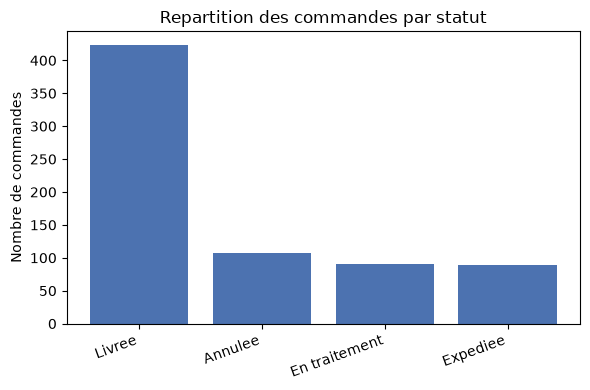

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(status_counts.index, status_counts.values, color="#4C72B0")
plt.ylabel("Nombre de commandes")
plt.title("Repartition des commandes par statut")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [19]:
cat = (
    fact.loc[fact["statut"] != "Annulee"]
    .groupby("categorie", as_index=False)["montant_ligne"].sum()
    .sort_values("montant_ligne", ascending=False)
)
cat["part_%"] = (cat["montant_ligne"] / cat["montant_ligne"].sum() * 100).round(1)
display(cat)

top_prod = (
    fact.loc[fact["statut"] != "Annulee"]
    .groupby(["id_produit", "nom_produit"], as_index=False)
    .agg(ca=("montant_ligne", "sum"), quantite=("quantite", "sum"))
    .sort_values("ca", ascending=False)
    .head(5)
)
display(top_prod)

,categorie,montant_ligne,part_%
3,Electronique,"123,113,500.00",51.40
5,Maison,"29,362,800.00",12.30
4,Loisir,"24,144,900.00",10.10
1,Bagagerie,"21,711,000.00",9.10
6,Vetement,"18,268,200.00",7.60
2,Beaute,"13,739,100.00",5.70
0,Alimentation,"9,209,000.00",3.80


,id_produit,nom_produit,ca,quantite
6,PRD007,Clavier mecanique,"23,669,800.00",29
1,PRD002,Ecouteurs sans fil,"23,107,200.00",29
5,PRD006,Souris sans fil,"19,243,800.00",40
8,PRD009,Powerbank 10000mAh,"17,593,700.00",28
0,PRD001,Smartphone,"15,654,800.00",29


**Constat.** L'électronique représente 51,4 % du chiffre d'affaires non annulé et constitue le principal moteur de revenus.

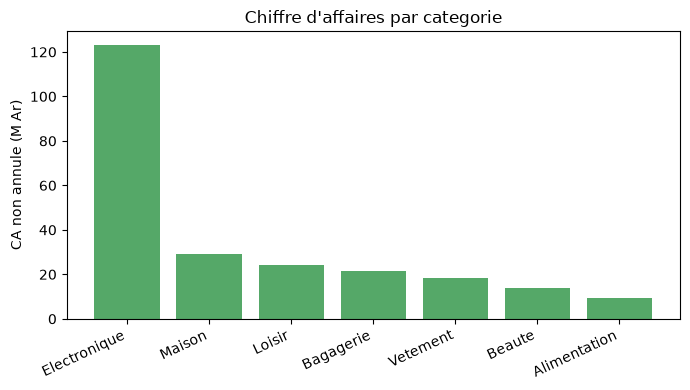

In [20]:
plt.figure(figsize=(7, 4))
plt.bar(cat["categorie"], cat["montant_ligne"] / 1e6, color="#55A868")
plt.ylabel("CA non annule (M Ar)")
plt.title("Chiffre d'affaires par categorie")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [21]:
top_clients = (
    order_level.loc[order_level.statut != "Annulee"]
    .dropna(subset=["id_client"])
    .groupby("id_client", as_index=False)["montant_commande"].sum()
    .sort_values("montant_commande", ascending=False)
)
ca_client_total = top_clients["montant_commande"].sum()
top5_part = top_clients.head(5)["montant_commande"].sum() / ca_client_total

print(f"Clients distincts ayant commande : {order_level['id_client'].dropna().nunique()}")
print(f"Part du CA (clients connus) portee par les 5 meilleurs clients : {top5_part:.1%}")
display(top_clients.head(5))

Clients distincts ayant commande : 190
Part du CA (clients connus) portee par les 5 meilleurs clients : 10.2%


,id_client,montant_commande
184,CLI0199,"5,656,800.00"
137,CLI0149,"5,631,600.00"
46,CLI0051,"4,933,200.00"
54,CLI0059,"4,120,700.00"
63,CLI0070,"4,036,200.00"


**Constat.** Les cinq principaux clients représentent 10,2 % du chiffre d'affaires réalisé auprès des clients identifiés.

In [22]:
geo = (
    fact.loc[fact["statut"] != "Annulee"]
    .groupby("ville", as_index=False)["montant_ligne"].sum()
    .sort_values("montant_ligne", ascending=False)
)
display(geo)

,ville,montant_ligne
1,Antsirabe,"49,112,300.00"
7,Toamasina,"36,380,600.00"
8,Toliara,"28,327,400.00"
3,Fianarantsoa,"26,583,200.00"
2,Antsiranana,"25,480,900.00"
6,Morondava,"24,875,200.00"
5,Mahajanga,"23,953,500.00"
0,Antananarivo,"22,226,000.00"
4,Inconnue,"2,609,400.00"


**Constat.** Antsirabe arrive en tête du chiffre d'affaires par ville avec 49,1 M Ar.

In [23]:
pay_status_counts = order_level["statut_paiement"].value_counts()
pay_status_pct = (pay_status_counts / pay_status_counts.sum() * 100).round(1)
display(pd.DataFrame({"commandes": pay_status_counts, "part_%": pay_status_pct}))

mode_summary = order_level.groupby("mode_paiement", dropna=True)["montant_paye"].agg(["count", "sum"])
display(mode_summary)

,commandes,part_%
statut_paiement,,
Valide,573,80.80
Echoue,70,9.90
Rembourse,66,9.30


,count,sum
mode_paiement,,
Carte bancaire,171,"68,693,100.00"
Especes a la livraison,184,"70,732,700.00"
Mobile Money,176,"70,539,300.00"
Virement,178,"71,992,300.00"


**Constat.** Les paiements sont répartis entre 80,8 % de statuts valides, 9,9 % échoués et 9,3 % remboursés.

Commandes avec un avis exploitable : 381 / 709 (53.7%)
Note moyenne (notes valides)       : 3.46/5
Part de notes 4 ou 5                : 53.8%

Correlation delai de livraison / note (n=220) : 0.11


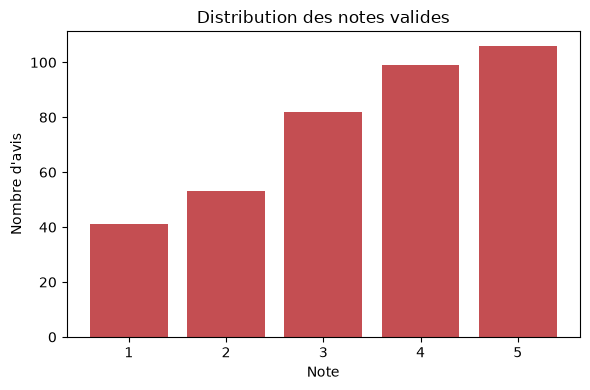

In [24]:
valid_notes = order_level["note"].dropna()
print(f"Commandes avec un avis exploitable : {len(valid_notes)} / {len(order_level)} ({len(valid_notes)/len(order_level):.1%})")
print(f"Note moyenne (notes valides)       : {valid_notes.mean():.2f}/5")
print(f"Part de notes 4 ou 5                : {(valid_notes >= 4).mean():.1%}")

delai = (pd.to_datetime(order_level["date_livraison"]) - pd.to_datetime(order_level["date_commande"])).dt.days
tmp = order_level.assign(delai=delai).dropna(subset=["delai", "note"])
corr = tmp["delai"].corr(tmp["note"])
print(f"\nCorrelation delai de livraison / note (n={len(tmp)}) : {corr:.2f}")

plt.figure(figsize=(6, 4))
plt.bar(sorted(valid_notes.value_counts().index), valid_notes.value_counts().sort_index(), color="#C44E52")
plt.xlabel("Note")
plt.ylabel("Nombre d'avis")
plt.title("Distribution des notes valides")
plt.tight_layout()
plt.show()

**Constat.** La note moyenne est de 3,46/5 sur 381 commandes avec un avis exploitable, dont 53,8 % obtiennent au moins 4/5.

## 4. Modèle dimensionnel

Construction d'une constellation de faits pour les ventes, paiements et avis, avec des dimensions client, produit et date.

In [25]:
all_dates = pd.concat([
    fact["date_commande"],
    fact["date_livraison"].dropna(),
    pd.to_datetime(pay_scope["date_paiement"], errors="coerce"),
    avis_c["date_avis_dt"].dropna(),
]).dropna()

dim_date = pd.DataFrame({"date": pd.date_range(all_dates.min().normalize(), all_dates.max().normalize(), freq="D")})
dim_date["date_key"] = dim_date["date"].dt.strftime("%Y%m%d").astype(int)
dim_date["annee"] = dim_date["date"].dt.year
dim_date["mois"] = dim_date["date"].dt.month
dim_date["nom_mois"] = dim_date["date"].dt.month_name()
dim_date["trimestre"] = "T" + dim_date["date"].dt.quarter.astype(str)
dim_date["jour_semaine"] = dim_date["date"].dt.day_name()

print("dim_date :", dim_date.shape, "- de", dim_date['date'].min().date(), "a", dim_date['date'].max().date())
display(dim_date.head(3))

dim_date : (430, 7) - de 2025-01-03 a 2026-03-08


,date,date_key,annee,mois,nom_mois,trimestre,jour_semaine
0,2025-01-03,20250103,2025,1,January,T1,Friday
1,2025-01-04,20250104,2025,1,January,T1,Saturday
2,2025-01-05,20250105,2025,1,January,T1,Sunday


In [26]:
fact_ventes = fact[[
    "id_commande", "id_client", "id_produit", "quantite", "montant_ligne", "statut", "date_commande"
]].copy()
fact_ventes["date_key"] = fact_ventes["date_commande"].dt.strftime("%Y%m%d").astype(int)
fact_ventes = fact_ventes.rename(columns={"statut": "statut_commande"})

fact_paiements = pay_scope[[
    "id_paiement", "id_commande", "id_client", "montant_paye_corrige",
    "mode_paiement", "statut_paiement_norm", "date_paiement"
]].copy()
fact_paiements["date_paiement_dt"] = pd.to_datetime(fact_paiements["date_paiement"], errors="coerce")
fact_paiements["date_key"] = fact_paiements["date_paiement_dt"].dt.strftime("%Y%m%d").astype("Int64")
fact_paiements = fact_paiements.rename(columns={
    "montant_paye_corrige": "montant_paye",
    "statut_paiement_norm": "statut_paiement"
})
fact_paiements = fact_paiements[[
    "id_paiement", "id_commande", "id_client", "montant_paye",
    "mode_paiement", "statut_paiement", "date_key"
]]

fact_avis = avis_c.dropna(subset=["date_avis_dt"]).merge(
    order_client, on="id_commande", how="inner"
).copy()
fact_avis["date_key"] = fact_avis["date_avis_dt"].dt.strftime("%Y%m%d").astype(int)
fact_avis = fact_avis[[
    "id_avis", "id_commande", "id_client", "note", "note_valide", "commentaire", "date_key"
]]

for name, df in [("fact_ventes", fact_ventes), ("fact_paiements", fact_paiements), ("fact_avis", fact_avis)]:
    print(f"{name} : {df.shape}")

assert fact_ventes["date_key"].isin(dim_date["date_key"]).all()
assert fact_paiements["date_key"].dropna().isin(dim_date["date_key"]).all()
assert fact_avis["date_key"].isin(dim_date["date_key"]).all()
assert fact_ventes["id_produit"].isin(dim_produit["id_produit"]).all()
print("\nContrôles de cohérence du modèle dimensionnel : OK")


fact_ventes : (1223, 8)
fact_paiements : (709, 7)
fact_avis : (400, 7)

Contrôles de cohérence du modèle dimensionnel : OK


In [27]:
OUT_DIR = Path("modele_dimensionnel")
OUT_DIR.mkdir(exist_ok=True)

fact.to_csv(OUT_DIR / "table_analytique_complete.csv", index=False)
fact_ventes.to_csv(OUT_DIR / "fact_ventes.csv", index=False)
fact_paiements.to_csv(OUT_DIR / "fact_paiements.csv", index=False)
fact_avis.to_csv(OUT_DIR / "fact_avis.csv", index=False)
dim_client.to_csv(OUT_DIR / "dim_client.csv", index=False)
dim_produit.to_csv(OUT_DIR / "dim_produit.csv", index=False)
dim_date.to_csv(OUT_DIR / "dim_date.csv", index=False)

for f in sorted(OUT_DIR.glob("*.csv")):
    print(f.name, "-", f.stat().st_size, "octets")

dim_client.csv - 19935 octets
dim_date.csv - 19690 octets
dim_produit.csv - 2643 octets
fact_avis.csv - 25909 octets
fact_paiements.csv - 46953 octets
fact_ventes.csv - 87945 octets
table_analytique_complete.csv - 277395 octets


### Exemples de requêtes

Le modèle permet d'analyser les ventes, revenus, paiements, satisfaction et délais par période, client, produit ou catégorie.

## 5. Qualité des données

Synthèse des anomalies détectées, des corrections appliquées et des points à surveiller.

In [28]:
anomalies = pd.DataFrame([
    ("Clients dupliques (email+telephone)", 14, "Corrige (dedoublonnes vers un id canonique)"),
    ("Identifiants clients CLI900x absents de clients.csv", n_client_inconnu_commandes, "Non corrige (aucune fiche inventee), signale"),
    ("Prix catalogue produit manquants", produits["prix_unitaire"].isna().sum(), "Complete dans dim_produit uniquement (mediane), jamais dans les ventes"),
    ("Lignes montant_ligne != prix_unitaire*quantite", 50, "Non corrige : montant_ligne verifie exact vs paiements ; prix_unitaire a documenter cote plateforme"),
    ("Paiements a signe corrige", 8, "Corrige (bug de signe confirme par recoupement avec le montant de la commande)"),
    ("Paiements orphelins (sans commande)", n_pay_orphelins, "Exclus de la table finale, signales"),
    ("Doublons stricts d'avis", n_avis_dup, "Corrige (supprimes)"),
    ("Notes hors intervalle 1-5", n_note_hors_bornes, "Conservees dans la table, exclues des indicateurs"),
    ("Avis sans note", n_note_manquante, "Conserves (commentaire garde), note absente"),
    ("Lignes avec livraison avant commande", len(incoh_liv), "Non corrige (cause inconnue), signale"),
    ("avis_clients.csv sans id_produit", 1, "Limite structurelle : pas d'analyse satisfaction x produit possible"),
], columns=["Anomalie", "Nombre", "Decision"])
display(anomalies)

,Anomalie,Nombre,Decision
0,Clients dupliques (email+telephone),14,Corrige (dedoublonnes vers un id canonique)
1,Identifiants clients CLI900x absents de client...,14,"Non corrige (aucune fiche inventee), signale"
2,Prix catalogue produit manquants,5,Complete dans dim_produit uniquement (mediane)...
3,Lignes montant_ligne != prix_unitaire*quantite,50,Non corrige : montant_ligne verifie exact vs p...
4,Paiements a signe corrige,8,Corrige (bug de signe confirme par recoupement...
5,Paiements orphelins (sans commande),10,"Exclus de la table finale, signales"
6,Doublons stricts d'avis,6,Corrige (supprimes)
7,Notes hors intervalle 1-5,10,"Conservees dans la table, exclues des indicateurs"
8,Avis sans note,9,"Conserves (commentaire garde), note absente"
9,Lignes avec livraison avant commande,11,"Non corrige (cause inconnue), signale"


# Conclusion

Les données permettent d'analyser l'activité commerciale, les clients, les produits, les paiements et la satisfaction.

Le modèle final fournit une base structurée pour des analyses récurrentes, tout en conservant les principales limites de qualité identifiées.